# 03 — Cohort Retention Analysis
**Business question this notebook answers:** What share of customers is retained month over month, and where does retention break down?

**Method:** group customers into monthly cohorts by their first purchase month, then track what fraction of each cohort keeps buying in subsequent months.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path("../data/processed")
df = pd.read_csv(PROCESSED_DIR / "transactions_clean.csv", parse_dates=["InvoiceDate"])

## 1. Assign each transaction to a cohort and a period index

In [2]:
df["OrderMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"] = df.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")
df["CohortIndex"] = (df["OrderMonth"] - df["CohortMonth"]).apply(lambda x: x.n)
df[["CustomerID", "OrderMonth", "CohortMonth", "CohortIndex"]].head()

,CustomerID,OrderMonth,CohortMonth,CohortIndex
0,13085,2009-12,2009-12,0
1,13085,2009-12,2009-12,0
2,13085,2009-12,2009-12,0
3,13085,2009-12,2009-12,0
4,13085,2009-12,2009-12,0


## 2. Build the cohort retention table

In [3]:
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
      .nunique()
      .reset_index()
)
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)
retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN


## 3. Visualize — the heatmap that goes straight into Power BI / the executive summary

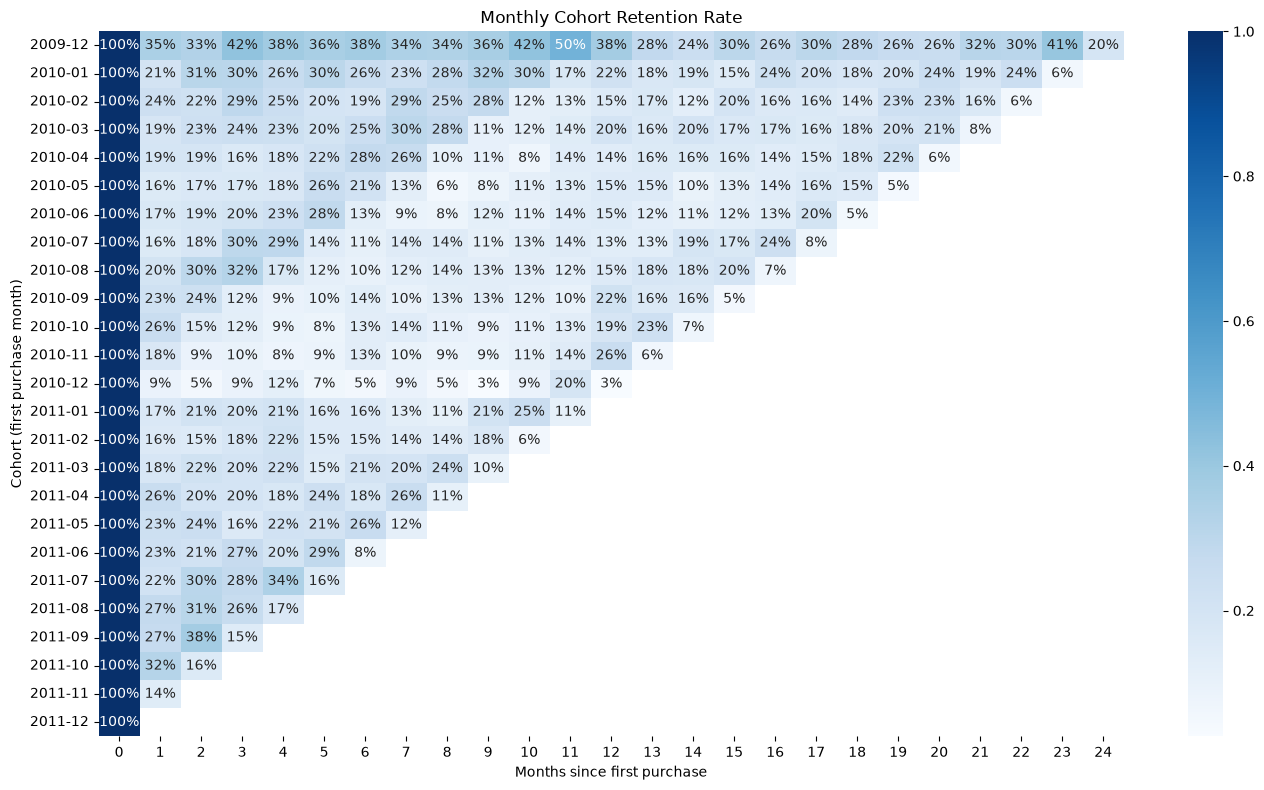

In [4]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Monthly Cohort Retention Rate")
plt.ylabel("Cohort (first purchase month)")
plt.xlabel("Months since first purchase")
plt.tight_layout()
plt.savefig("../figures/cohort_retention_heatmap.png", dpi=150)
plt.show()

## 4. Save the table for Power BI

In [5]:
out_path = PROCESSED_DIR / "cohort_table.csv"
retention.to_csv(out_path)
print(f"Saved: {out_path}")

Saved: ..\data\processed\cohort_table.csv


## Summary

- Built a monthly cohort retention matrix from first purchase date.
- **[Fill in once run]**: retention falls to **[XX%]** by month **[N]**, which is the concrete window the recommendations section should target with a re-engagement action.
- This table feeds the Retention View in the Power BI dashboard directly.